# Autoencoder-Only First-Frame Readout

This notebook isolates the autoencoder question: if we train only the AE with very little trajectory data, does the first-frame latent value `z0` correlate with final p-ratio and static stiffness descriptors, including near-zero stiffness edge counts?

Sweep:
- latent sizes: `1, 2`
- training networks: `1, 2, 4`
- training frames per network: `1, 2, 4`
- repeats per setting: `5`
- trajectory frame skip: every `15`th raw frame
- no latent propagator
- evaluation: first-frame `z0` on validation and test networks


In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display

from graph_utils import calc_p_ratio_rollout_sides
from course_project.data import resolve_dataset_splits
from course_project.models.latent_space_simulator import NodeDeltaAttentionAutoEncoder
from course_project.utils import resolve_device

plt.rcParams['figure.dpi'] = 120


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
print('run seed:', seed)

latent_dims = [1, 2]
train_counts = [1, 2, 4]
train_frame_counts = [1, 2, 4]
repeat_count = 3

cfg = {
    'dataset_path': '../data/new_reid_combined.pt',
    'val_count': 25,
    'latent_dim': 1,  # overwritten by latent_dims during the sweep
    'latent_tokens': 12,
    'hidden_size': 128,
    'pos_dim': 2,
    'batch_graphs': 8,
    'frame_skip': 15,
    'near_zero_stiffness_threshold': 1e-3,
    'progress_eval_max_frames': 20,
    'progress_eval_max_sims': 25,
    'ae_max_epochs': 60,
    'ae_patience': 20,
    'ae_lr': 1e-3,
    'ae_weight_decay': 1e-5,
    'early_stop_min_delta': 1e-5,
    'node_feature_mode': 'delta',
    'split_seed': seed,
    'shuffle_dataset_within_source': True,
    'device': 'auto',
    'output_root': 'results/autoencoder_first_frame_readout',
}


def resolve_existing_path(path_like):
    path = Path(path_like)
    if path.exists():
        return str(path)
    if str(path).startswith('../'):
        repo_relative_path = Path(str(path)[3:])
        if repo_relative_path.exists():
            return str(repo_relative_path)
    return str(path)

cfg['dataset_path'] = resolve_existing_path(cfg['dataset_path'])
device = resolve_device(cfg['device'])
run_dir = Path(cfg['output_root'])
run_dir.mkdir(parents=True, exist_ok=True)
print('device:', device)
print('output:', run_dir)
display(pd.DataFrame([cfg]))


run seed: 414945146
device: cuda
output: results/autoencoder_first_frame_readout


,dataset_path,val_count,latent_dim,latent_tokens,hidden_size,pos_dim,batch_graphs,frame_skip,near_zero_stiffness_threshold,progress_eval_max_frames,...,ae_max_epochs,ae_patience,ae_lr,ae_weight_decay,early_stop_min_delta,node_feature_mode,split_seed,shuffle_dataset_within_source,device,output_root
0,../data/new_reid_combined.pt,25,1,12,128,2,8,15,0.001,20,...,60,20,0.001,0.00001,0.00001,delta,414945146,True,auto,results/autoencoder_first_frame_readout


In [3]:
def filtered_frame_ids(sim, *, include_last=False, max_frames=None):
    stop = len(sim) if include_last else len(sim) - 1
    step = max(1, int(cfg.get('frame_skip', 1)))
    frame_ids = list(range(0, max(stop, 0), step))
    if max_frames is not None:
        frame_ids = frame_ids[:int(max_frames)]
    return [int(t) for t in frame_ids]


def make_frame_index(sims, *, max_frames_per_sim=None, include_last=True):
    rows = []
    for sim_idx, sim in enumerate(sims):
        frame_ids = filtered_frame_ids(sim, include_last=include_last, max_frames=max_frames_per_sim)
        rows.extend((sim_idx, int(t)) for t in frame_ids)
    return rows


def iter_batches(rows, batch_graphs, *, shuffle=True):
    rows = list(rows)
    if shuffle:
        random.shuffle(rows)
    for i in range(0, len(rows), int(batch_graphs)):
        yield rows[i:i + int(batch_graphs)]


def pearson_r(a, b):
    a = pd.Series(a, dtype=float)
    b = pd.Series(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3 or np.isclose(a[mask].std(), 0.0) or np.isclose(b[mask].std(), 0.0):
        return float('nan')
    return float(a[mask].corr(b[mask]))


def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 2:
        return float('nan')
    y = y_true[mask]
    pred = y_pred[mask]
    ss_res = float(np.sum((y - pred) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')


def linear_fit_on_val_eval_test(val_df, test_df, x_col, y_col='final_p_ratio'):
    val_pair = val_df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    test_pair = test_df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(val_pair) < 2 or len(test_pair) < 2 or np.isclose(val_pair[x_col].std(), 0.0):
        return float('nan')
    coef = np.polyfit(val_pair[x_col].to_numpy(dtype=float), val_pair[y_col].to_numpy(dtype=float), deg=1)
    pred = coef[0] * test_pair[x_col].to_numpy(dtype=float) + coef[1]
    return r2_score(test_pair[y_col], pred)


In [4]:
def edge_features(ref_graph, cur_graph, *, device):
    ref_e = ref_graph.edge_attr.to(device).float()
    cur_e = cur_graph.edge_attr.to(device).float()
    ref_vec = ref_e[:, :cfg['pos_dim']]
    cur_vec = cur_e[:, :cfg['pos_dim']]
    ref_len = ref_e[:, cfg['pos_dim']:cfg['pos_dim'] + 1]
    cur_len = cur_e[:, cfg['pos_dim']:cfg['pos_dim'] + 1]
    stiffness = ref_e[:, -1:]
    stretch = cur_len - ref_len
    rel_stretch = stretch / ref_len.clamp_min(1e-6)
    return torch.cat([ref_vec, cur_vec, ref_len, cur_len, stretch, rel_stretch, stiffness, cur_e], dim=-1)


def frame_node_feature(sim, t, *, mode, device):
    t = int(t)
    cur_pos = sim[t].x[:, :cfg['pos_dim']].to(device).float()
    if mode in ('position', 'positions'):
        return cur_pos
    if mode == 'delta':
        ref_pos = sim[0].x[:, :cfg['pos_dim']].to(device).float()
        return cur_pos - ref_pos
    if mode == 'velocity':
        if t <= 0:
            return torch.zeros_like(cur_pos)
        prev_pos = sim[t - 1].x[:, :cfg['pos_dim']].to(device).float()
        return cur_pos - prev_pos
    raise ValueError(f'Unknown node_feature_mode: {mode}')


def batch_delta_graphs(sims, rows, *, device, node_feature_mode='delta'):
    deltas = []
    node_features = []
    ref_positions = []
    edge_attrs = []
    ref_edge_attrs = []
    edge_indices = []
    batch = []
    node_offset = 0
    for local_idx, (sim_idx, t) in enumerate(rows):
        sim = sims[int(sim_idx)]
        ref_graph = sim[0]
        cur_graph = sim[int(t)]
        ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
        cur_pos = cur_graph.x[:, :cfg['pos_dim']].to(device).float()
        deltas.append(cur_pos - ref_pos)
        node_features.append(frame_node_feature(sim, t, mode=node_feature_mode, device=device))
        ref_positions.append(ref_pos)
        edge_attrs.append(edge_features(ref_graph, cur_graph, device=device))
        ref_edge_attrs.append(edge_features(ref_graph, ref_graph, device=device))
        edge_indices.append(ref_graph.edge_index.to(device).long() + node_offset)
        batch.append(torch.full((ref_pos.size(0),), local_idx, dtype=torch.long, device=device))
        node_offset += ref_pos.size(0)
    return {
        'delta': torch.cat(deltas, dim=0),
        'node_feature': torch.cat(node_features, dim=0),
        'ref_pos': torch.cat(ref_positions, dim=0),
        'edge_attr': torch.cat(edge_attrs, dim=0),
        'ref_edge_attr': torch.cat(ref_edge_attrs, dim=0),
        'edge_index': torch.cat(edge_indices, dim=1),
        'batch': torch.cat(batch, dim=0),
    }


def fit_tensor_stats(chunks):
    values = torch.cat(chunks, dim=0)
    mean = values.mean(dim=0, keepdim=True)
    std = values.std(dim=0, keepdim=True).clamp_min(1e-6)
    return mean, std


def fit_stats(sims, frame_rows):
    delta_chunks = []
    node_feature_chunks = []
    edge_chunks = []
    for rows in iter_batches(frame_rows, cfg['batch_graphs'], shuffle=False):
        batch_data = batch_delta_graphs(sims, rows, device=device, node_feature_mode=cfg['node_feature_mode'])
        delta_chunks.append(batch_data['delta'])
        node_feature_chunks.append(batch_data['node_feature'])
        edge_chunks.append(batch_data['edge_attr'])
        edge_chunks.append(batch_data['ref_edge_attr'])
    delta_mean, delta_std = fit_tensor_stats(delta_chunks)
    node_feature_mean, node_feature_std = fit_tensor_stats(node_feature_chunks)
    edge_mean, edge_std = fit_tensor_stats(edge_chunks)
    return {
        'delta_mean': delta_mean,
        'delta_std': delta_std,
        'node_feature_mean': node_feature_mean,
        'node_feature_std': node_feature_std,
        'edge_mean': edge_mean,
        'edge_std': edge_std,
    }


def normalize(x, mean, std):
    return (x - mean.to(x.device)) / std.to(x.device)


In [5]:
def _unique_initial_edges(graph):
    pos = graph.x[:, :cfg['pos_dim']].detach().cpu().float().numpy()
    edge_index = graph.edge_index.detach().cpu().numpy()
    edge_attr = graph.edge_attr.detach().cpu().float().numpy()
    pair_rows = {}
    for e in range(edge_index.shape[1]):
        i, j = int(edge_index[0, e]), int(edge_index[1, e])
        if i == j:
            continue
        key = (i, j) if i < j else (j, i)
        if key in pair_rows:
            continue
        vec = pos[j] - pos[i]
        length = float(np.linalg.norm(vec))
        stiffness = float(edge_attr[e, -1]) if edge_attr.size else np.nan
        pair_rows[key] = {'i': key[0], 'j': key[1], 'vec': vec, 'length': length, 'stiffness': stiffness}
    return list(pair_rows.values())


def _safe_mean(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanmean(values)) if values.size and np.isfinite(values).any() else np.nan


def _safe_std(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanstd(values)) if values.size and np.isfinite(values).any() else np.nan


def initial_descriptor_row(sim, sim_idx, *, split):
    edges = _unique_initial_edges(sim[0])
    stiffness = np.asarray([edge['stiffness'] for edge in edges], dtype=float)
    near_zero_threshold = float(cfg.get('near_zero_stiffness_threshold', 1e-3))
    near_zero_count = int((np.abs(stiffness) <= near_zero_threshold).sum()) if stiffness.size else 0
    horizontal = []
    vertical = []
    diagonal = []
    for edge in edges:
        if edge['length'] <= 1e-12:
            continue
        unit = edge['vec'] / edge['length']
        if abs(float(unit[0])) >= 0.85:
            horizontal.append(edge['stiffness'])
        elif abs(float(unit[1])) >= 0.85:
            vertical.append(edge['stiffness'])
        else:
            diagonal.append(edge['stiffness'])
    return {
        'split': split,
        'sim_idx': int(sim_idx),
        'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1)),
        'edge_count': int(len(edges)),
        'stiffness_mean': _safe_mean(stiffness),
        'stiffness_std': _safe_std(stiffness),
        'near_zero_stiffness_threshold': near_zero_threshold,
        'near_zero_stiffness_edge_count': near_zero_count,
        'near_zero_stiffness_edge_fraction': float(near_zero_count / len(edges)) if edges else np.nan,
        'horizontal_stiffness': _safe_mean(horizontal),
        'vertical_stiffness': _safe_mean(vertical),
        'diagonal_stiffness': _safe_mean(diagonal),
    }


In [6]:
def ae_epoch(model, sims, frame_rows, stats, *, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses = []
    for rows in iter_batches(frame_rows, cfg['batch_graphs'], shuffle=is_train):
        batch_data = batch_delta_graphs(sims, rows, device=device, node_feature_mode=cfg['node_feature_mode'])
        delta_norm = normalize(batch_data['delta'], stats['delta_mean'], stats['delta_std'])
        node_feature_norm = normalize(batch_data['node_feature'], stats['node_feature_mean'], stats['node_feature_std'])
        edge_attr_norm = normalize(batch_data['edge_attr'], stats['edge_mean'], stats['edge_std'])
        ref_edge_attr_norm = normalize(batch_data['ref_edge_attr'], stats['edge_mean'], stats['edge_std'])
        recon_norm, _ = model(
            node_feature_norm,
            batch_data['ref_pos'],
            edge_attr_norm,
            ref_edge_attr_norm,
            batch_data['edge_index'],
            batch_data['batch'],
        )
        loss = F.mse_loss(recon_norm, delta_norm)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else float('nan')


def encode_frame(model, sim, t, stats):
    model.eval()
    with torch.no_grad():
        ref_graph = sim[0]
        cur_graph = sim[int(t)]
        ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
        node_feature = frame_node_feature(sim, t, mode=cfg['node_feature_mode'], device=device)
        edge_attr = edge_features(ref_graph, cur_graph, device=device)
        ref_edge_attr = edge_features(ref_graph, ref_graph, device=device)
        batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
        z, _ = model.encode(
            normalize(node_feature, stats['node_feature_mean'], stats['node_feature_std']),
            ref_pos,
            normalize(edge_attr, stats['edge_mean'], stats['edge_std']),
            normalize(ref_edge_attr, stats['edge_mean'], stats['edge_std']),
            ref_graph.edge_index.to(device).long(),
            batch,
        )
    return z.squeeze(0).detach().cpu().numpy()


def first_frame_latent_table(model, sims, stats, *, split):
    rows = []
    for sim_idx, sim in enumerate(sims):
        row = initial_descriptor_row(sim, sim_idx, split=split)
        z = encode_frame(model, sim, 0, stats)
        for dim_idx, value in enumerate(z):
            row[f'z{dim_idx}'] = float(value)
        rows.append(row)
    return pd.DataFrame(rows)


def trajectory_progress_latent_table(model, sims, stats, *, split, max_sims=None, max_frames=None):
    rows = []
    eval_sims = sims[:int(max_sims)] if max_sims is not None else sims
    for sim_idx, sim in enumerate(eval_sims):
        frame_ids = filtered_frame_ids(sim, include_last=True, max_frames=max_frames)
        frame_count = len(frame_ids)
        final_p_ratio = float(calc_p_ratio_rollout_sides(sim, -1))
        for frame_order, frame_idx in enumerate(frame_ids):
            z = encode_frame(model, sim, int(frame_idx), stats)
            row = {
                'split': split,
                'sim_idx': int(sim_idx),
                'frame': int(frame_idx),
                'frame_order': int(frame_order),
                'frame_frac': float(frame_order / max(frame_count - 1, 1)),
                'final_p_ratio': final_p_ratio,
            }
            for dim_idx, value in enumerate(z):
                row[f'z{dim_idx}'] = float(value)
            rows.append(row)
    return pd.DataFrame(rows)


In [7]:
def train_autoencoder_case(latent_dim, train_count, train_frames, repeat_idx):
    repeat_seed = int(cfg['split_seed']) + 1009 * int(repeat_idx) + 7919 * int(latent_dim) + 9173 * int(train_count) + 101 * int(train_frames)
    random.seed(repeat_seed)
    np.random.seed(repeat_seed)
    torch.manual_seed(repeat_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(repeat_seed)

    train_data, val_data, test_data, split_info = resolve_dataset_splits(
        cfg['dataset_path'],
        train_count=int(train_count),
        val_count=int(cfg['val_count']),
        split_seed=repeat_seed,
        shuffle_within_source=cfg.get('shuffle_dataset_within_source', False),
    )
    frame_rows = make_frame_index(train_data, max_frames_per_sim=int(train_frames), include_last=True)
    val_frame_rows = make_frame_index(val_data, max_frames_per_sim=4, include_last=True)
    stats = fit_stats(train_data, frame_rows)
    edge_dim = int(stats['edge_mean'].numel())

    model = NodeDeltaAttentionAutoEncoder(
        pos_dim=cfg['pos_dim'],
        edge_dim=edge_dim,
        hidden_size=cfg['hidden_size'],
        latent_dim=int(latent_dim),
        latent_tokens=cfg['latent_tokens'],
    ).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg['ae_lr'], weight_decay=cfg['ae_weight_decay'])
    best_state = None
    best_val = float('inf')
    stale = 0
    history = []
    label = f'CV{latent_dim} | repeat={repeat_idx} | nets={train_count} | frames={train_frames}'
    for epoch in range(1, int(cfg['ae_max_epochs']) + 1):
        train_loss = ae_epoch(model, train_data, frame_rows, stats, optimizer=opt)
        with torch.no_grad():
            val_loss = ae_epoch(model, val_data, val_frame_rows, stats, optimizer=None)
        history.append({
            'latent_dim': int(latent_dim),
            'repeat': int(repeat_idx),
            'seed': int(repeat_seed),
            'train_networks': int(train_count),
            'train_frames_per_network': int(train_frames),
            'epoch': epoch,
            'train_mse_norm': train_loss,
            'val_mse_norm': val_loss,
        })
        if val_loss < best_val - cfg['early_stop_min_delta']:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
        if epoch == 1 or epoch % 10 == 0 or stale == 0:
            print(f'{label} ae {epoch:03d} train={train_loss:.5g} val={val_loss:.5g} stale={stale}')
        if stale >= int(cfg['ae_patience']):
            break
    model.load_state_dict(best_state)
    model.eval()

    val_latents = first_frame_latent_table(model, val_data, stats, split='val')
    test_latents = first_frame_latent_table(model, test_data, stats, split='test')
    progress_latents = trajectory_progress_latent_table(
        model,
        test_data,
        stats,
        split='test',
        max_sims=cfg.get('progress_eval_max_sims'),
        max_frames=cfg.get('progress_eval_max_frames'),
    )
    for df in [val_latents, test_latents, progress_latents]:
        df['latent_dim'] = int(latent_dim)
        df['repeat'] = int(repeat_idx)
        df['seed'] = int(repeat_seed)
        df['train_networks'] = int(train_count)
        df['train_frames_per_network'] = int(train_frames)
    history_df = pd.DataFrame(history)
    return {
        'label': label,
        'latent_dim': int(latent_dim),
        'repeat': int(repeat_idx),
        'seed': int(repeat_seed),
        'train_networks': int(train_count),
        'train_frames_per_network': int(train_frames),
        'split_info': split_info,
        'history': history_df,
        'val_latents': val_latents,
        'test_latents': test_latents,
        'progress_latents': progress_latents,
        'best_val_mse_norm': best_val,
    }


In [8]:
ae_results = []
for latent_dim in latent_dims:
    for repeat_idx in range(1, repeat_count + 1):
        for train_count in train_counts:
            for train_frames in train_frame_counts:
                print(f'\n### AE-only run: CV{latent_dim}, repeat={repeat_idx}/{repeat_count}, networks={train_count}, frames={train_frames}')
                ae_results.append(train_autoencoder_case(latent_dim, train_count, train_frames, repeat_idx))
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

all_history_df = pd.concat([r['history'] for r in ae_results], ignore_index=True)
first_frame_latent_df = pd.concat(
    [r['val_latents'] for r in ae_results] + [r['test_latents'] for r in ae_results],
    ignore_index=True,
)
trajectory_progress_latent_df = pd.concat([r['progress_latents'] for r in ae_results], ignore_index=True)
best_history_df = (
    all_history_df
    .groupby(['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network'])['val_mse_norm']
    .min()
    .reset_index()
)
best_history_summary_df = (
    best_history_df
    .groupby(['latent_dim', 'train_networks', 'train_frames_per_network'])['val_mse_norm']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
display(best_history_summary_df.round(6))
display(first_frame_latent_df.head().round(4))
display(trajectory_progress_latent_df.head().round(4))



### AE-only run: CV1, repeat=1/3, networks=1, frames=1
CV1 | repeat=1 | nets=1 | frames=1 ae 001 train=0.001653 val=2.4346e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 004 train=0.00042837 val=2.4346e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 005 train=0.00017972 val=2.4345e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 006 train=6.3982e-05 val=2.4344e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 007 train=6.6235e-05 val=2.4344e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 008 train=9.7456e-05 val=2.4344e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 010 train=9.2639e-05 val=2.4344e+06 stale=2
CV1 | repeat=1 | nets=1 | frames=1 ae 020 train=2.7157e-05 val=2.4345e+06 stale=12

### AE-only run: CV1, repeat=1/3, networks=1, frames=2
CV1 | repeat=1 | nets=1 | frames=2 ae 001 train=1.0001 val=40.984 stale=0
CV1 | repeat=1 | nets=1 | frames=2 ae 002 train=0.97648 val=40.948 stale=0
CV1 | repeat=1 | nets=1 | frames=2 ae 003 train=0.95293 val=40.899 stale=0
CV1 | rep

,latent_dim,train_networks,train_frames_per_network,mean,std,count
0,1,1,1,2.318126e+06,103495.704952,3
1,1,1,2,2.677639e+01,18.723577,3
2,1,1,4,8.239290e-01,0.367708,3
3,1,2,1,2.332931e+06,45609.738558,3
4,1,2,2,1.884413e+01,14.041779,3
5,1,2,4,5.713270e-01,0.316765,3
6,1,4,1,2.324204e+06,112896.538184,3
7,1,4,2,7.290837e+00,4.264911,3
8,1,4,4,2.608520e-01,0.035782,3
9,2,1,1,2.368752e+06,79955.809895,3


,split,sim_idx,final_p_ratio,edge_count,stiffness_mean,stiffness_std,near_zero_stiffness_threshold,near_zero_stiffness_edge_count,near_zero_stiffness_edge_fraction,horizontal_stiffness,vertical_stiffness,diagonal_stiffness,z0,latent_dim,repeat,seed,train_networks,train_frames_per_network,z1
0,val,0,0.2104,541,0.4662,0.1540,0.001,0,0.0000,0.4371,0.5911,0.3303,-0.1066,1,1,414963348,1,1,NaN
1,val,1,-0.1981,286,0.6541,0.3818,0.001,1,0.0035,0.6819,0.8269,0.3790,-0.1449,1,1,414963348,1,1,NaN
2,val,2,0.1270,483,0.5395,0.2384,0.001,0,0.0000,0.5263,0.6952,0.2958,-0.1203,1,1,414963348,1,1,NaN
3,val,3,0.0730,480,0.5592,0.2720,0.001,0,0.0000,0.5740,0.7423,0.3073,-0.1257,1,1,414963348,1,1,NaN
4,val,4,-0.2124,482,0.6209,0.3937,0.001,22,0.0456,0.6799,0.7875,0.2764,-0.1407,1,1,414963348,1,1,NaN


,split,sim_idx,frame,frame_order,frame_frac,final_p_ratio,z0,latent_dim,repeat,seed,train_networks,train_frames_per_network,z1
0,test,0,0,0,0.0000,0.1503,-0.1117,1,1,414963348,1,1,NaN
1,test,0,15,1,0.0526,0.1503,-51.0634,1,1,414963348,1,1,NaN
2,test,0,30,2,0.1053,0.1503,-121.3374,1,1,414963348,1,1,NaN
3,test,0,45,3,0.1579,0.1503,-194.1909,1,1,414963348,1,1,NaN
4,test,0,60,4,0.2105,0.1503,-268.3944,1,1,414963348,1,1,NaN


In [9]:
targets = [
    'final_p_ratio',
    'stiffness_mean',
    'stiffness_std',
    'near_zero_stiffness_edge_count',
    'near_zero_stiffness_edge_fraction',
    'horizontal_stiffness',
    'vertical_stiffness',
    'diagonal_stiffness',
]

corr_rows = []
for (latent_dim, repeat_idx, train_count, train_frames, split), group in first_frame_latent_df.groupby(['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network', 'split'], sort=False):
    z_cols = [col for col in group.columns if col.startswith('z')]
    for z_col in z_cols:
        for target in targets:
            if target not in group.columns or group[target].nunique(dropna=True) < 2:
                continue
            r = pearson_r(group[z_col], group[target])
            corr_rows.append({
                'latent_dim': int(latent_dim),
                'repeat': int(repeat_idx),
                'train_networks': int(train_count),
                'train_frames_per_network': int(train_frames),
                'split': split,
                'signal': z_col,
                'target': target,
                'pearson_r': r,
                'corr_r2': r * r if np.isfinite(r) else np.nan,
                'n': int(group[[z_col, target]].dropna().shape[0]),
            })

# Baseline static descriptor -> final p-ratio, using the same test/val networks.
for (latent_dim, repeat_idx, train_count, train_frames, split), group in first_frame_latent_df.groupby(['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network', 'split'], sort=False):
    for descriptor in [c for c in targets if c != 'final_p_ratio']:
        if descriptor not in group.columns or group[descriptor].nunique(dropna=True) < 2:
            continue
        r = pearson_r(group[descriptor], group['final_p_ratio'])
        corr_rows.append({
            'latent_dim': int(latent_dim),
            'repeat': int(repeat_idx),
            'train_networks': int(train_count),
            'train_frames_per_network': int(train_frames),
            'split': split,
            'signal': descriptor,
            'target': 'final_p_ratio',
            'pearson_r': r,
            'corr_r2': r * r if np.isfinite(r) else np.nan,
            'n': int(group[[descriptor, 'final_p_ratio']].dropna().shape[0]),
        })

corr_df = pd.DataFrame(corr_rows)

# Fit only the 1D z0 -> final-p-ratio calibration on validation and report test R2.
readout_rows = []
for (latent_dim, repeat_idx, train_count, train_frames), _ in first_frame_latent_df.groupby(['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network'], sort=False):
    val_df = first_frame_latent_df[
        first_frame_latent_df['latent_dim'].eq(latent_dim)
        & first_frame_latent_df['repeat'].eq(repeat_idx)
        & first_frame_latent_df['train_networks'].eq(train_count)
        & first_frame_latent_df['train_frames_per_network'].eq(train_frames)
        & first_frame_latent_df['split'].eq('val')
    ]
    test_df = first_frame_latent_df[
        first_frame_latent_df['latent_dim'].eq(latent_dim)
        & first_frame_latent_df['repeat'].eq(repeat_idx)
        & first_frame_latent_df['train_networks'].eq(train_count)
        & first_frame_latent_df['train_frames_per_network'].eq(train_frames)
        & first_frame_latent_df['split'].eq('test')
    ]
    readout_rows.append({
        'latent_dim': int(latent_dim),
        'repeat': int(repeat_idx),
        'train_networks': int(train_count),
        'train_frames_per_network': int(train_frames),
        'val_z0_final_p_ratio_r': pearson_r(val_df['z0'], val_df['final_p_ratio']),
        'test_z0_final_p_ratio_r': pearson_r(test_df['z0'], test_df['final_p_ratio']),
        'test_z0_final_p_ratio_corr_r2': pearson_r(test_df['z0'], test_df['final_p_ratio']) ** 2,
        'test_z0_final_p_ratio_val_fit_r2': linear_fit_on_val_eval_test(val_df, test_df, 'z0'),
    })
readout_summary_df = pd.DataFrame(readout_rows)
readout_mean_df = (
    readout_summary_df
    .groupby(['latent_dim', 'train_networks', 'train_frames_per_network'])
    .agg(
        test_z0_final_p_ratio_corr_r2_mean=('test_z0_final_p_ratio_corr_r2', 'mean'),
        test_z0_final_p_ratio_corr_r2_std=('test_z0_final_p_ratio_corr_r2', 'std'),
        test_z0_final_p_ratio_val_fit_r2_mean=('test_z0_final_p_ratio_val_fit_r2', 'mean'),
        test_z0_final_p_ratio_val_fit_r2_std=('test_z0_final_p_ratio_val_fit_r2', 'std'),
        repeats=('repeat', 'count'),
    )
    .reset_index()
)

display(readout_mean_df.round(4))
display(readout_summary_df.round(4))
display(
    (
        corr_df[corr_df['split'].eq('test')]
        .groupby(['latent_dim', 'train_networks', 'train_frames_per_network', 'signal', 'target'], as_index=False)
        .agg(pearson_r_mean=('pearson_r', 'mean'), pearson_r_std=('pearson_r', 'std'), corr_r2_mean=('corr_r2', 'mean'), corr_r2_std=('corr_r2', 'std'), n=('n', 'mean'))
        .sort_values(['train_networks', 'train_frames_per_network', 'corr_r2_mean'], ascending=[True, True, False])
        .groupby(['latent_dim', 'train_networks', 'train_frames_per_network'])
        .head(8)
    )
    .round(4)
)


,latent_dim,train_networks,train_frames_per_network,test_z0_final_p_ratio_corr_r2_mean,test_z0_final_p_ratio_corr_r2_std,test_z0_final_p_ratio_val_fit_r2_mean,test_z0_final_p_ratio_val_fit_r2_std,repeats
0,1,1,1,0.4942,0.2768,0.4396,0.2941,3
1,1,1,2,0.3912,0.2229,0.2251,0.2847,3
2,1,1,4,0.6116,0.2008,0.5411,0.2915,3
3,1,2,1,0.5155,0.0666,0.4805,0.0408,3
4,1,2,2,0.7447,0.0088,0.7407,0.0066,3
5,1,2,4,0.7625,0.0291,0.7433,0.0449,3
6,1,4,1,0.3759,0.3138,0.2884,0.4385,3
7,1,4,2,0.8032,0.0207,0.7272,0.0363,3
8,1,4,4,0.7983,0.0423,0.7876,0.0412,3
9,2,1,1,0.4655,0.4005,0.3892,0.4900,3


,latent_dim,repeat,train_networks,train_frames_per_network,val_z0_final_p_ratio_r,test_z0_final_p_ratio_r,test_z0_final_p_ratio_corr_r2,test_z0_final_p_ratio_val_fit_r2
0,1,1,1,1,0.7640,0.8701,0.7570,0.7171
1,1,1,1,2,0.6977,0.7928,0.6286,0.5378
2,1,1,1,4,-0.9462,-0.8674,0.7524,0.7522
3,1,1,2,1,0.8211,0.7327,0.5369,0.5022
4,1,1,2,2,0.8590,0.8571,0.7346,0.7330
5,1,1,2,4,0.9488,0.8899,0.7920,0.7906
6,1,1,4,1,-0.8474,-0.8045,0.6472,0.6311
7,1,1,4,2,0.8604,0.8828,0.7794,0.6870
8,1,1,4,4,0.9077,0.8662,0.7504,0.7401
9,1,2,1,1,0.4256,0.4530,0.2052,0.1312


,latent_dim,train_networks,train_frames_per_network,signal,target,pearson_r_mean,pearson_r_std,corr_r2_mean,corr_r2_std,n
5,1,1,1,stiffness_std,final_p_ratio,-0.9492,0.0071,0.9011,0.0134,76.0
212,2,1,1,stiffness_std,final_p_ratio,-0.9465,0.0047,0.8958,0.0089,76.0
1,1,1,1,horizontal_stiffness,final_p_ratio,-0.9367,0.0103,0.8774,0.0193,76.0
208,2,1,1,horizontal_stiffness,final_p_ratio,-0.9328,0.0109,0.8702,0.0204,76.0
4,1,1,1,stiffness_mean,final_p_ratio,-0.8935,0.0122,0.7985,0.0218,76.0
...,...,...,...,...,...,...,...,...,...,...
403,2,4,4,z0,stiffness_mean,0.1618,1.0205,0.7204,0.3871,73.0
397,2,4,4,vertical_stiffness,final_p_ratio,-0.8437,0.0209,0.7121,0.0354,73.0
411,2,4,4,z1,stiffness_mean,0.3350,0.9353,0.6954,0.1220,73.0
400,2,4,4,z0,horizontal_stiffness,0.1354,0.9728,0.6492,0.3980,73.0


In [10]:
progress_corr_rows = []
for (latent_dim, repeat_idx, train_count, train_frames, split), group in trajectory_progress_latent_df.groupby(
    ['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network', 'split'], sort=False
):
    z_cols = [col for col in group.columns if col.startswith('z')]
    for z_col in z_cols:
        pair = group[[z_col, 'frame_frac']].replace([np.inf, -np.inf], np.nan).dropna()
        r = pearson_r(pair[z_col], pair['frame_frac']) if len(pair) >= 3 else float('nan')
        progress_corr_rows.append({
            'latent_dim': int(latent_dim),
            'repeat': int(repeat_idx),
            'train_networks': int(train_count),
            'train_frames_per_network': int(train_frames),
            'split': split,
            'signal': z_col,
            'target': 'trajectory_progress_frame_frac',
            'pearson_r': r,
            'corr_r2': r * r if np.isfinite(r) else np.nan,
            'n': int(len(pair)),
        })

trajectory_progress_corr_df = pd.DataFrame(progress_corr_rows)
trajectory_progress_summary_df = (
    trajectory_progress_corr_df
    .groupby(['latent_dim', 'train_networks', 'train_frames_per_network', 'signal'], as_index=False)
    .agg(
        progress_corr_r_mean=('pearson_r', 'mean'),
        progress_corr_r_std=('pearson_r', 'std'),
        progress_corr_r2_mean=('corr_r2', 'mean'),
        progress_corr_r2_std=('corr_r2', 'std'),
        repeats=('repeat', 'count'),
        n=('n', 'mean'),
    )
)
display(trajectory_progress_summary_df.round(4))


,latent_dim,train_networks,train_frames_per_network,signal,progress_corr_r_mean,progress_corr_r_std,progress_corr_r2_mean,progress_corr_r2_std,repeats,n
0,1,1,1,z0,-0.2361,1.0505,0.7915,0.2476,3,500.0
1,1,1,1,z1,NaN,NaN,NaN,NaN,3,0.0
2,1,1,2,z0,-0.7145,0.0584,0.5128,0.0823,3,500.0
3,1,1,2,z1,NaN,NaN,NaN,NaN,3,0.0
4,1,1,4,z0,-0.2328,0.9415,0.6451,0.1158,3,500.0
5,1,1,4,z1,NaN,NaN,NaN,NaN,3,0.0
6,1,2,1,z0,-0.3695,0.1767,0.1573,0.1371,3,500.0
7,1,2,1,z1,NaN,NaN,NaN,NaN,3,0.0
8,1,2,2,z0,0.1125,0.7028,0.3419,0.1514,3,500.0
9,1,2,2,z1,NaN,NaN,NaN,NaN,3,0.0


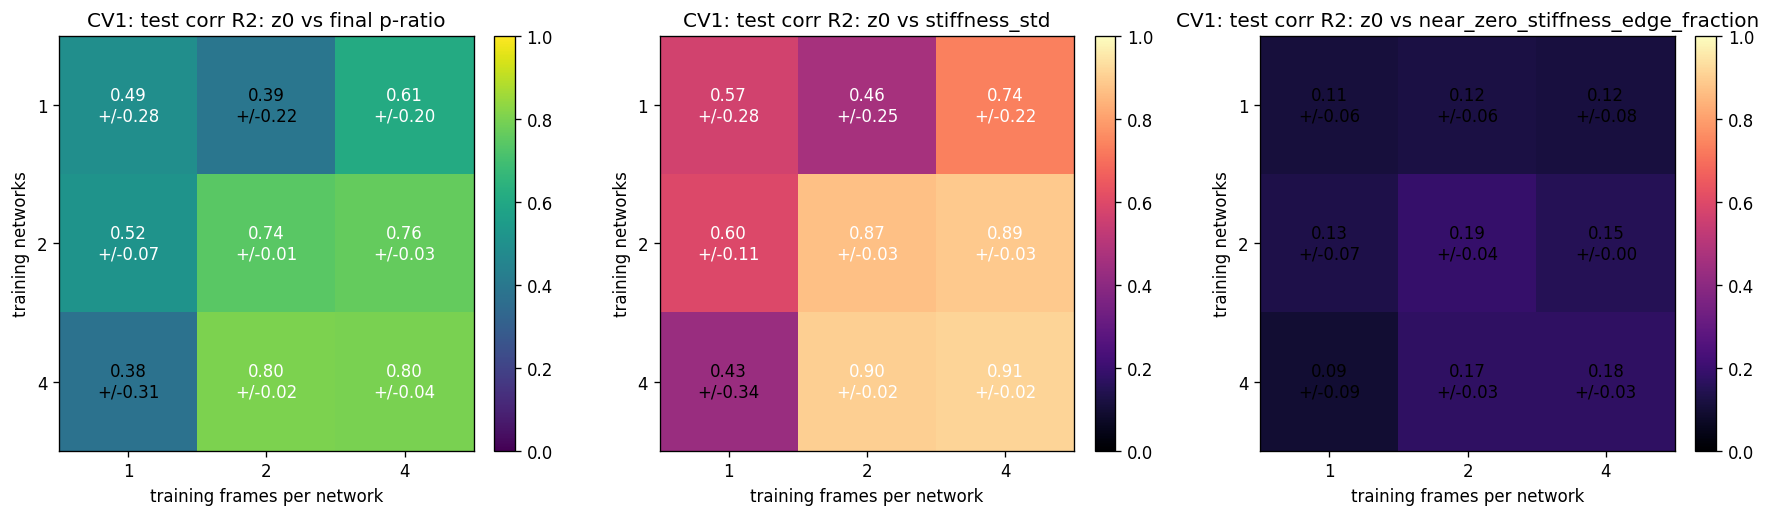

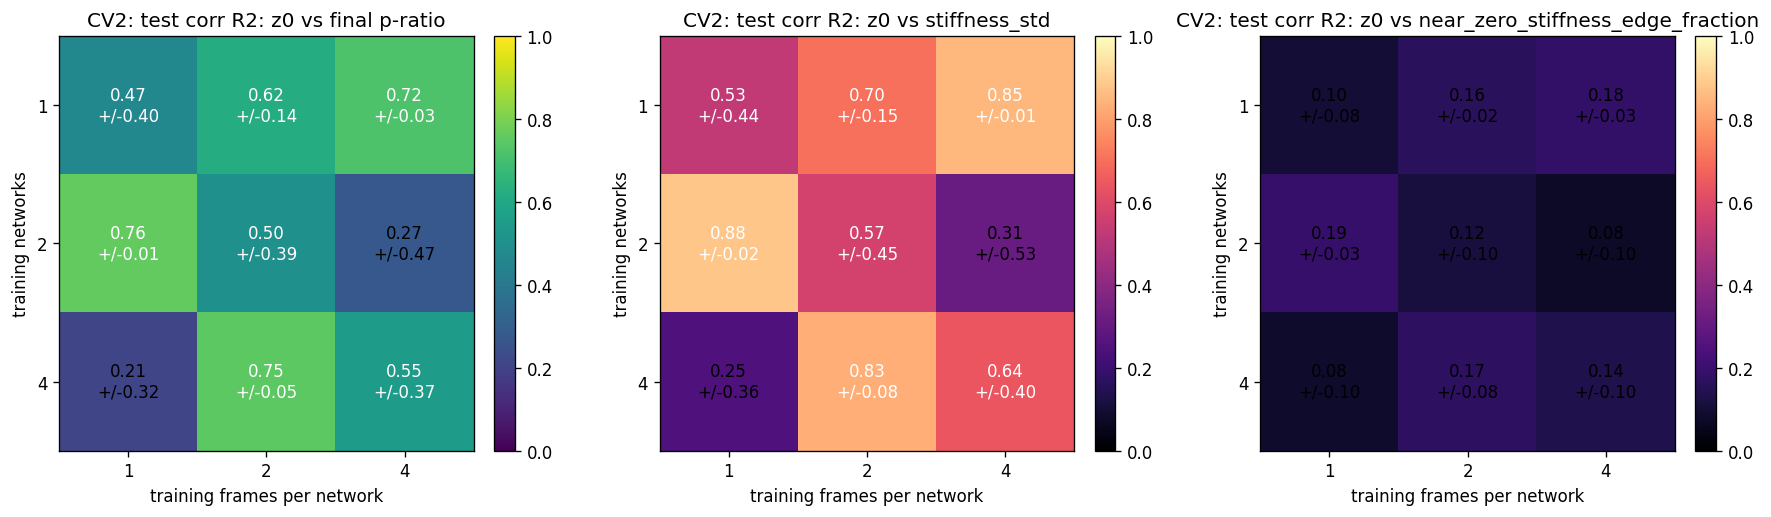

In [11]:
for latent_dim in latent_dims:
    fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2), constrained_layout=True)
    readout_plot_df = readout_mean_df[readout_mean_df['latent_dim'].eq(latent_dim)]

    heat = readout_plot_df.pivot(index='train_networks', columns='train_frames_per_network', values='test_z0_final_p_ratio_corr_r2_mean')
    heat_std = readout_plot_df.pivot(index='train_networks', columns='train_frames_per_network', values='test_z0_final_p_ratio_corr_r2_std')
    im = axes[0].imshow(heat.to_numpy(dtype=float), vmin=0, vmax=1, cmap='viridis')
    axes[0].set_xticks(range(len(heat.columns)), heat.columns)
    axes[0].set_yticks(range(len(heat.index)), heat.index)
    axes[0].set_xlabel('training frames per network')
    axes[0].set_ylabel('training networks')
    axes[0].set_title(f'CV{latent_dim}: test corr R2: z0 vs final p-ratio')
    for i, idx in enumerate(heat.index):
        for j, col in enumerate(heat.columns):
            val = heat.loc[idx, col]
            sd = heat_std.loc[idx, col]
            axes[0].text(j, i, f'{val:.2f}\n+/-{sd:.2f}', ha='center', va='center', color='white' if val > 0.45 else 'black')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    for ax, target in zip(axes[1:], ['stiffness_std', 'near_zero_stiffness_edge_fraction']):
        plot_df = (
            corr_df[
                corr_df['split'].eq('test')
                & corr_df['latent_dim'].eq(latent_dim)
                & corr_df['signal'].eq('z0')
                & corr_df['target'].eq(target)
            ]
            .groupby(['train_networks', 'train_frames_per_network'], as_index=False)
            .agg(corr_r2_mean=('corr_r2', 'mean'), corr_r2_std=('corr_r2', 'std'))
        )
        heat_t = plot_df.pivot(index='train_networks', columns='train_frames_per_network', values='corr_r2_mean')
        heat_t_std = plot_df.pivot(index='train_networks', columns='train_frames_per_network', values='corr_r2_std')
        im_t = ax.imshow(heat_t.to_numpy(dtype=float), vmin=0, vmax=1, cmap='magma')
        ax.set_xticks(range(len(heat_t.columns)), heat_t.columns)
        ax.set_yticks(range(len(heat_t.index)), heat_t.index)
        ax.set_xlabel('training frames per network')
        ax.set_ylabel('training networks')
        ax.set_title(f'CV{latent_dim}: test corr R2: z0 vs {target}')
        for i, idx in enumerate(heat_t.index):
            for j, col in enumerate(heat_t.columns):
                val = heat_t.loc[idx, col]
                sd = heat_t_std.loc[idx, col]
                ax.text(j, i, f'{val:.2f}\n+/-{sd:.2f}', ha='center', va='center', color='white' if val > 0.45 else 'black')
        fig.colorbar(im_t, ax=ax, fraction=0.046, pad=0.04)
    plt.show()


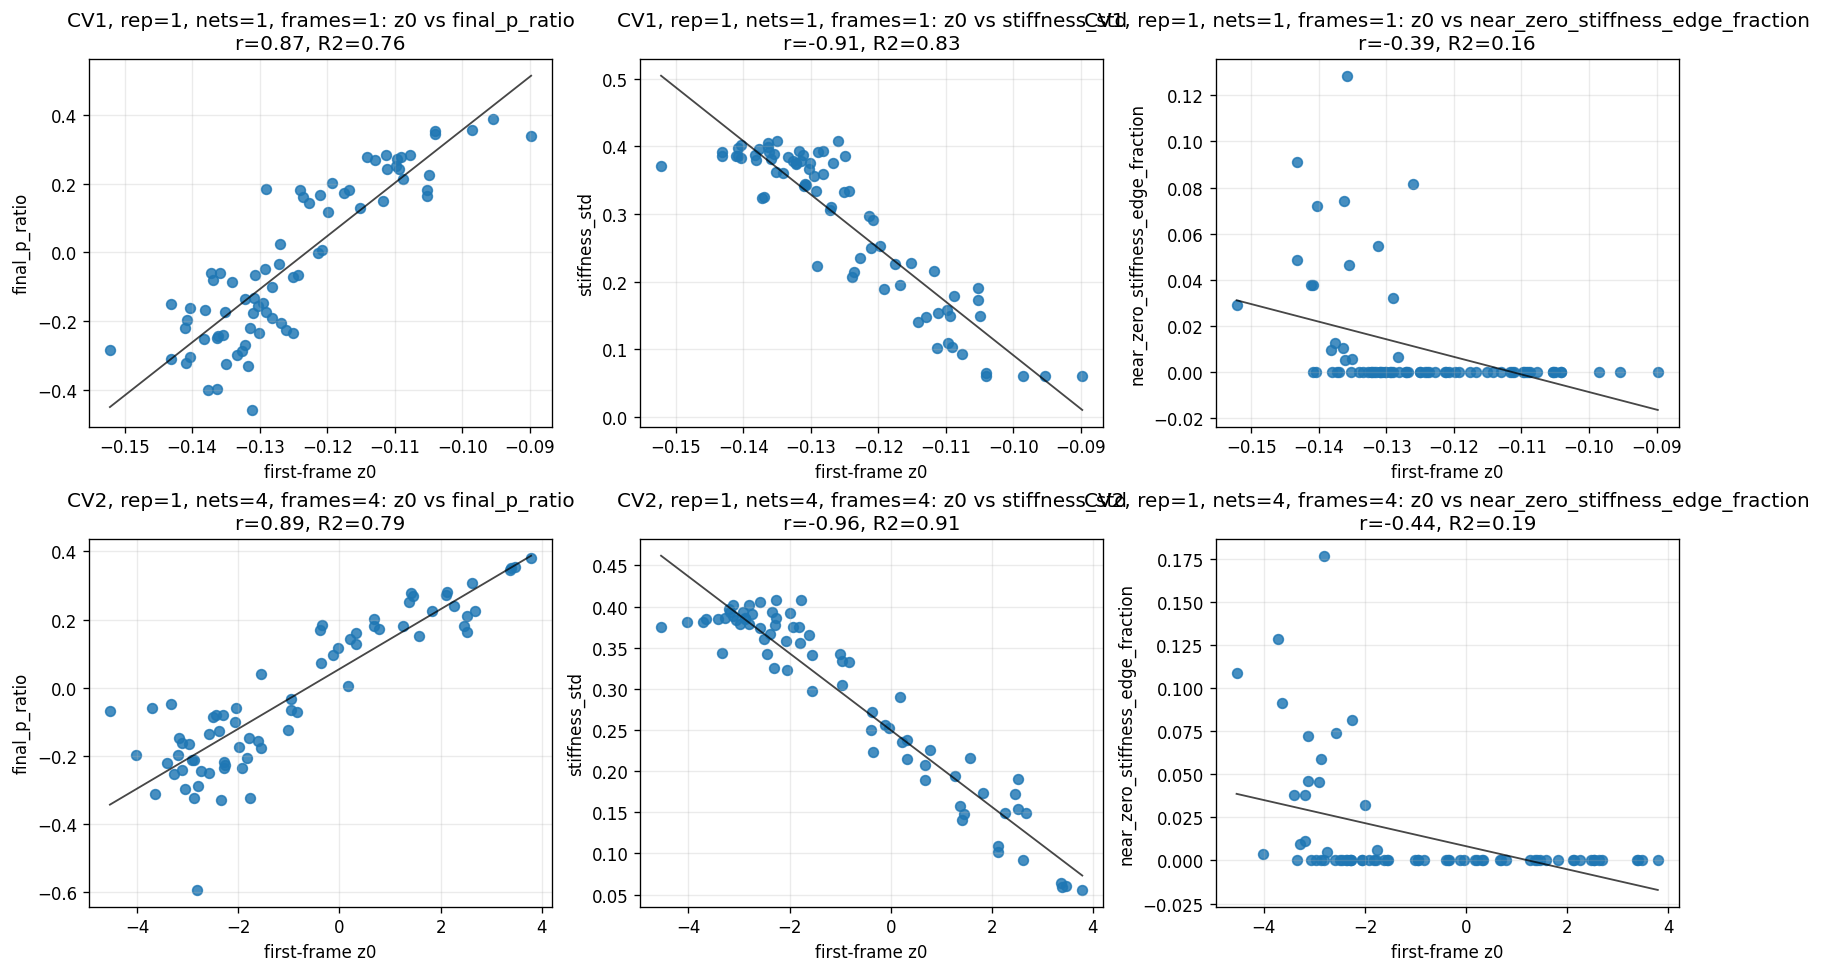

In [12]:
# Representative scatter plots for the most minimal and most data-rich AE-only cases.
scatter_cases = [(1, 1, 1, 1), (2, 1, 4, 4)]
fig, axes = plt.subplots(len(scatter_cases), 3, figsize=(14.0, 4.0 * len(scatter_cases)), squeeze=False, constrained_layout=True)
for row_idx, (latent_dim, repeat_idx, train_count, train_frames) in enumerate(scatter_cases):
    group = first_frame_latent_df[
        first_frame_latent_df['split'].eq('test')
        & first_frame_latent_df['latent_dim'].eq(latent_dim)
        & first_frame_latent_df['repeat'].eq(repeat_idx)
        & first_frame_latent_df['train_networks'].eq(train_count)
        & first_frame_latent_df['train_frames_per_network'].eq(train_frames)
    ].copy()
    for ax, y_col in zip(axes[row_idx], ['final_p_ratio', 'stiffness_std', 'near_zero_stiffness_edge_fraction']):
        plot_df = group[['z0', y_col]].replace([np.inf, -np.inf], np.nan).dropna()
        ax.scatter(plot_df['z0'], plot_df[y_col], s=34, alpha=0.82)
        if len(plot_df) >= 2 and plot_df['z0'].nunique() > 1:
            coef = np.polyfit(plot_df['z0'], plot_df[y_col], deg=1)
            xs = np.linspace(float(plot_df['z0'].min()), float(plot_df['z0'].max()), 100)
            ax.plot(xs, coef[0] * xs + coef[1], color='black', lw=1.1, alpha=0.72)
        r = pearson_r(plot_df['z0'], plot_df[y_col])
        ax.set_title(f'CV{latent_dim}, rep={repeat_idx}, nets={train_count}, frames={train_frames}: z0 vs {y_col}\nr={r:.2f}, R2={r*r:.2f}' if np.isfinite(r) else f'z0 vs {y_col}')
        ax.set_xlabel('first-frame z0')
        ax.set_ylabel(y_col)
        ax.grid(alpha=0.25)
plt.show()


In [13]:
export_dir = run_dir / 'exports'
export_dir.mkdir(parents=True, exist_ok=True)
all_history_df.to_csv(export_dir / 'ae_history.csv', index=False)
first_frame_latent_df.to_csv(export_dir / 'first_frame_latents.csv', index=False)
trajectory_progress_latent_df.to_csv(export_dir / 'trajectory_progress_latents.csv', index=False)
corr_df.to_csv(export_dir / 'z_descriptor_correlations.csv', index=False)
trajectory_progress_corr_df.to_csv(export_dir / 'z_trajectory_progress_correlations.csv', index=False)
trajectory_progress_summary_df.to_csv(export_dir / 'z_trajectory_progress_summary.csv', index=False)
readout_summary_df.to_csv(export_dir / 'z0_pratio_readout_by_repeat.csv', index=False)
readout_mean_df.to_csv(export_dir / 'z0_pratio_readout_summary.csv', index=False)
print(f'wrote exports to {export_dir}')


wrote exports to results/autoencoder_first_frame_readout/exports
